In [49]:
import re
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
from collections import Counter
import emoji
import seaborn as sns

In [2]:
f=open("WhatsApp Chat with Squad of Data Scientist .txt","r",encoding="utf-8")
data=f.read()

In [3]:
print(data)

12/1/25, 12:34 PM - Messages and calls are end-to-end encrypted. Only people in this chat can read, listen to, or share them. Learn more.
7/26/24, 10:03 AM - Sarvesh(B.Tech) created group "Squad of Data Scientist "
7/26/24, 10:03 AM - You were added
11/17/25, 1:01 AM - Suryadip(B.Tech): Waiting for this message
11/17/25, 2:18 AM - Sarvesh(B.Tech): Waiting for this message
11/17/25, 11:11 AM - Suryadip(B.Tech): Waiting for this message
11/18/25, 6:55 PM - Parineeta(Class CR): Waiting for this message
11/18/25, 6:56 PM - Sarvesh(B.Tech): Waiting for this message
11/18/25, 7:18 PM - Ishika(Class CR): 😂
11/18/25, 7:24 PM - Parineeta(Class CR): Waiting for this message
11/20/25, 7:53 PM - +91 89275 73159: POLL:
NPTEL cirtificate pabi?
OPTION: Ha (1 vote)
OPTION: Na (0 votes)

11/20/25, 9:17 PM - Sourav(B Tech): Waiting for this message
11/20/25, 9:17 PM - Sourav(B Tech): Waiting for this message
11/24/25, 3:42 PM - Sudipta(B.Tech): Hall 3 te aay
11/29/25, 9:54 PM - Sarvesh(B.Tech): Waiting 

In [4]:
pattern = r'^(\d{1,2}/\d{1,2}/\d{2,4}),\s(\d{1,2}:\d{2}\s[AP]M)\s-\s([^:]+):\s(.+)$'

messages = re.findall(pattern, data, flags=re.MULTILINE)

print(len(messages))

595


In [5]:
list_messages = [list(msg) for msg in messages]
list_messages

[['11/17/25', '1:01\u202fAM', 'Suryadip(B.Tech)', 'Waiting for this message'],
 ['11/17/25', '2:18\u202fAM', 'Sarvesh(B.Tech)', 'Waiting for this message'],
 ['11/17/25', '11:11\u202fAM', 'Suryadip(B.Tech)', 'Waiting for this message'],
 ['11/18/25',
  '6:55\u202fPM',
  'Parineeta(Class CR)',
  'Waiting for this message'],
 ['11/18/25', '6:56\u202fPM', 'Sarvesh(B.Tech)', 'Waiting for this message'],
 ['11/18/25', '7:18\u202fPM', 'Ishika(Class CR)', '😂'],
 ['11/18/25',
  '7:24\u202fPM',
  'Parineeta(Class CR)',
  'Waiting for this message'],
 ['11/20/25', '7:53\u202fPM', '+91 89275 73159', 'POLL:'],
 ['11/20/25', '9:17\u202fPM', 'Sourav(B Tech)', 'Waiting for this message'],
 ['11/20/25', '9:17\u202fPM', 'Sourav(B Tech)', 'Waiting for this message'],
 ['11/24/25', '3:42\u202fPM', 'Sudipta(B.Tech)', 'Hall 3 te aay'],
 ['11/29/25', '9:54\u202fPM', 'Sarvesh(B.Tech)', 'Waiting for this message'],
 ['11/29/25', '9:54\u202fPM', 'Sarvesh(B.Tech)', 'Waiting for this message'],
 ['11/29/25', '9:

In [6]:
df = pd.DataFrame(list_messages, columns=['date_str', 'time_str', 'user', 'message'])
df['message_date'] = pd.to_datetime(df['date_str'] + ' ' + df['time_str'])
df = df.drop(columns=['date_str', 'time_str'])
df.head()

C:\Users\USER\AppData\Local\Temp\ipykernel_4712\3898923604.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['message_date'] = pd.to_datetime(df['date_str'] + ' ' + df['time_str'])


,user,message,message_date
0,Suryadip(B.Tech),Waiting for this message,2025-11-17 01:01:00
1,Sarvesh(B.Tech),Waiting for this message,2025-11-17 02:18:00
2,Suryadip(B.Tech),Waiting for this message,2025-11-17 11:11:00
3,Parineeta(Class CR),Waiting for this message,2025-11-18 18:55:00
4,Sarvesh(B.Tech),Waiting for this message,2025-11-18 18:56:00


In [7]:
df['user_message'] = df['user'] + ': ' + df['message']
df.rename(columns={'message_date': 'date'}, inplace=True)
df = df[['user_message', 'date']]
df.head()

,user_message,date
0,Suryadip(B.Tech): Waiting for this message,2025-11-17 01:01:00
1,Sarvesh(B.Tech): Waiting for this message,2025-11-17 02:18:00
2,Suryadip(B.Tech): Waiting for this message,2025-11-17 11:11:00
3,Parineeta(Class CR): Waiting for this message,2025-11-18 18:55:00
4,Sarvesh(B.Tech): Waiting for this message,2025-11-18 18:56:00


In [8]:
df.shape

(595, 2)

In [9]:
users = []
messages = []

for message in df['user_message']:
    entry = re.split('^([\w\W]+?):\s', message)
    
    if entry[1:]: 
        users.append(entry[1])
        messages.append(entry[2])
    else: 
        users.append('group_notification')
        messages.append(entry[0])

df['user'] = users
df['message'] = messages

df.drop(columns=['user_message'], inplace=True)

df.head()

,date,user,message
0,2025-11-17 01:01:00,Suryadip(B.Tech),Waiting for this message
1,2025-11-17 02:18:00,Sarvesh(B.Tech),Waiting for this message
2,2025-11-17 11:11:00,Suryadip(B.Tech),Waiting for this message
3,2025-11-18 18:55:00,Parineeta(Class CR),Waiting for this message
4,2025-11-18 18:56:00,Sarvesh(B.Tech),Waiting for this message


In [10]:
df["year"]=df["date"].dt.year

In [11]:
df.head()

,date,user,message,year
0,2025-11-17 01:01:00,Suryadip(B.Tech),Waiting for this message,2025
1,2025-11-17 02:18:00,Sarvesh(B.Tech),Waiting for this message,2025
2,2025-11-17 11:11:00,Suryadip(B.Tech),Waiting for this message,2025
3,2025-11-18 18:55:00,Parineeta(Class CR),Waiting for this message,2025
4,2025-11-18 18:56:00,Sarvesh(B.Tech),Waiting for this message,2025


In [12]:
df["month"]=df["date"].dt.month_name()

In [13]:
df["Day"]=df["date"].dt.day

In [14]:
df["hour"]=df["date"].dt.hour
df["minute"]=df["date"].dt.minute
df.head()

,date,user,message,year,month,Day,hour,minute
0,2025-11-17 01:01:00,Suryadip(B.Tech),Waiting for this message,2025,November,17,1,1
1,2025-11-17 02:18:00,Sarvesh(B.Tech),Waiting for this message,2025,November,17,2,18
2,2025-11-17 11:11:00,Suryadip(B.Tech),Waiting for this message,2025,November,17,11,11
3,2025-11-18 18:55:00,Parineeta(Class CR),Waiting for this message,2025,November,18,18,55
4,2025-11-18 18:56:00,Sarvesh(B.Tech),Waiting for this message,2025,November,18,18,56


In [15]:
df.rename(columns={"Day":"day"},inplace=True)
df.head()

,date,user,message,year,month,day,hour,minute
0,2025-11-17 01:01:00,Suryadip(B.Tech),Waiting for this message,2025,November,17,1,1
1,2025-11-17 02:18:00,Sarvesh(B.Tech),Waiting for this message,2025,November,17,2,18
2,2025-11-17 11:11:00,Suryadip(B.Tech),Waiting for this message,2025,November,17,11,11
3,2025-11-18 18:55:00,Parineeta(Class CR),Waiting for this message,2025,November,18,18,55
4,2025-11-18 18:56:00,Sarvesh(B.Tech),Waiting for this message,2025,November,18,18,56


In [16]:
words=[]
for message in df["message"]:
    words.extend(message.split())

In [17]:
len(words)

2553

In [18]:
from urlextract import URLExtract
extractor=URLExtract()
urls=extractor.find_urls("Let's have URL stackoverflow.com as an example google.com, https://facebook.com, ftp://url.in .")
urls

['stackoverflow.com', 'google.com', 'https://facebook.com', 'ftp://url.in']

In [19]:
import re

links = []
url_pattern = r'(https?://\S+|www\.\S+)'

for message in df["message"]:
    urls = re.findall(url_pattern, message)
    links.extend(urls)
links

['https://onlinecourses.nptel.ac.in/noc26_cs86/preview',
 'https://chatgpt.com/share/6996e1bc-b4ac-800d-bd13-8f338cfb574e',
 'https://www.instagram.com/reel/DVRJJtqDx2J/?igsh=NmNrMGhxejJlZ3E0',
 'https://www.facebook.com/share/r/1CMfErHyhf/']

In [20]:
x=df["user"].value_counts().head()

In [21]:
name=x.index
count=x.values

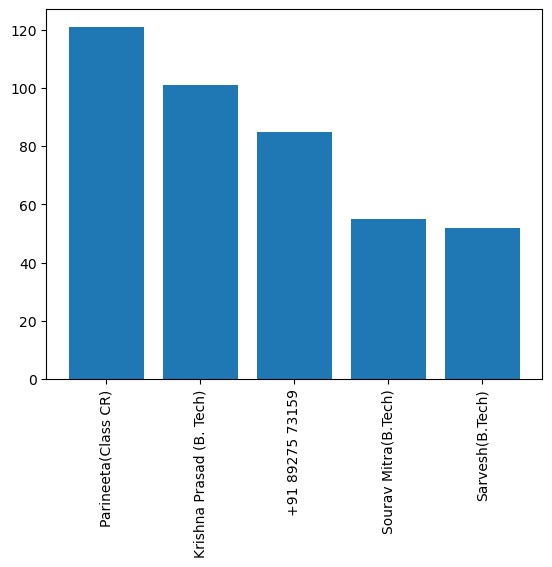

In [22]:
plt.bar(name,count)
plt.xticks(rotation="vertical")
plt.show()

In [23]:
round((df["user"].value_counts()/df.shape[0])*100,2).reset_index().rename(columns={"user":"name","count":"percent"})

,name,percent
0,Parineeta(Class CR),20.34
1,Krishna Prasad (B. Tech),16.97
2,+91 89275 73159,14.29
3,Sourav Mitra(B.Tech),9.24
4,Sarvesh(B.Tech),8.74
5,No.18 ❤️‍🔥,8.24
6,Ishika(Class CR),6.05
7,Bhawesh Sinha(B.Tech),5.04
8,Suryadip(B.Tech),3.53
9,Debojit(B. Tech),2.86


In [24]:
words=[]
for message in df["message"]:
    words.extend(message.split())
words

['Waiting',
 'for',
 'this',
 'message',
 'Waiting',
 'for',
 'this',
 'message',
 'Waiting',
 'for',
 'this',
 'message',
 'Waiting',
 'for',
 'this',
 'message',
 'Waiting',
 'for',
 'this',
 'message',
 '😂',
 'Waiting',
 'for',
 'this',
 'message',
 'POLL:',
 'Waiting',
 'for',
 'this',
 'message',
 'Waiting',
 'for',
 'this',
 'message',
 'Hall',
 '3',
 'te',
 'aay',
 'Waiting',
 'for',
 'this',
 'message',
 'Waiting',
 'for',
 'this',
 'message',
 'Waiting',
 'for',
 'this',
 'message',
 'Waiting',
 'for',
 'this',
 'message',
 'Waiting',
 'for',
 'this',
 'message',
 'Ye',
 'to',
 'hona',
 'hi',
 'tha....',
 'Ye',
 'log',
 'bahar',
 'fauj',
 'banake',
 'rakhtey',
 'hai',
 'Waiting',
 'for',
 'this',
 'message',
 'Waiting',
 'for',
 'this',
 'message',
 'Haa...hum',
 'log',
 'woha..satyajit',
 'ray',
 'open',
 'stage',
 'k',
 'samne',
 'the..tab',
 'hua..maina',
 'dekha..ek',
 'bohat',
 'jor',
 'awaj',
 'aya..bomb',
 'fatne',
 'jaisa..boom',
 'karke..phir..wo',
 'kach',
 'upar',
 

In [25]:
import string

stop_words = ['media', 'omitted', 'message', 'deleted', 'poll', 'waiting', 'this', 'was', 'for', 'the', 'and', 'that', 
              'hai', 'ki', 'ke', 'ka', 'ko', 'se', 'na', 'ne', 'mein', 'hi', 'bhi', 'tho', 'to', 're', 'oi', 'ar', 'hoy', 
              'na', 'ei', 'o', 'e', 'edited', 'joined', 'left', 'added', 'removed', 'group', 'description', 
              'tui', 'kal', 'bhai', 'ta', 'nhi', 'are', 'er', 'sir'] 

temp = df[df['user'] != 'group_notification']
temp = temp[temp['message'] != '<Media omitted>\n']

words = []

for message in temp['message']:
    clean_message = emoji.replace_emoji(message, replace='')
    clean_message=re.sub(r'[^a-zA-Z\s]','',clean_message)
    clean_message = clean_message.translate(str.maketrans('', '', string.punctuation))
    
    for word in clean_message.lower().split():
        if word not in stop_words and len(word)>=2 and word.isalpha():
            words.append(word)

most_common_df = pd.DataFrame(Counter(words).most_common(20))

In [26]:
most_common_df

,0,1
0,class,23
1,exam,20
2,hobe,11
3,ami,11
4,training,11
5,te,10
6,naa,9
7,koi,9
8,kore,9
9,nehi,8


In [27]:
df["month_num"]=df["date"].dt.month
df.sample(5)

,date,user,message,year,month,day,hour,minute,month_num
441,2026-03-05 23:29:00,Parineeta(Class CR),<Media omitted>,2026,March,5,23,29,3
542,2026-03-09 11:05:00,Bhawesh Sinha(B.Tech),Online exam k liye visa lgega,2026,March,9,11,5,3
481,2026-03-09 00:01:00,Parineeta(Class CR),Tahole ki korbi??,2026,March,9,0,1,3
100,2026-01-06 12:10:00,Sourav Mitra(B.Tech),Faltu giye ato time bose thaka,2026,January,6,12,10,1
511,2026-03-09 00:07:00,No.18 ❤️‍🔥,Are Sangita ma'am prottek bar ই same lekhe।।।।...,2026,March,9,0,7,3


In [28]:
timeline=df.groupby(["year","month_num","month"]).count()["message"].reset_index()

In [29]:
timeline

,year,month_num,month,message
0,2025,11,November,48
1,2025,12,December,26
2,2026,1,January,136
3,2026,2,February,196
4,2026,3,March,189


In [30]:
time=[]
for i in range(timeline.shape[0]):
    time.append(timeline["month"][i]+"-"+str(timeline["year"][i]))

In [31]:
time

['November-2025',
 'December-2025',
 'January-2026',
 'February-2026',
 'March-2026']

In [32]:
timeline["time"]=time
timeline

,year,month_num,month,message,time
0,2025,11,November,48,November-2025
1,2025,12,December,26,December-2025
2,2026,1,January,136,January-2026
3,2026,2,February,196,February-2026
4,2026,3,March,189,March-2026


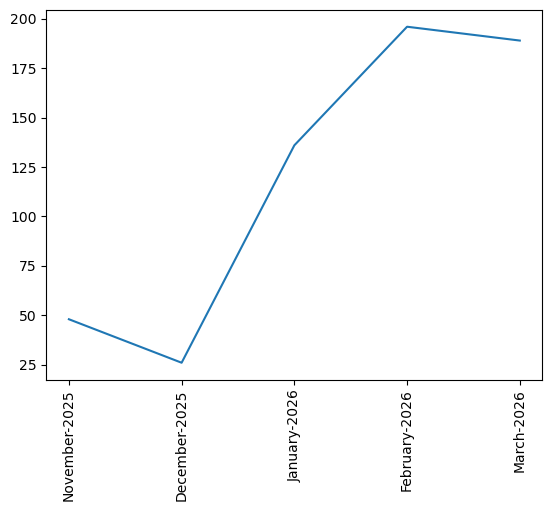

In [33]:
plt.plot(timeline["time"],timeline["message"])
plt.xticks(rotation="vertical")
plt.show()

In [35]:
df["only_date"]=df["date"].dt.date

In [38]:
daily_timeline=df.groupby("only_date").count()["message"].reset_index()

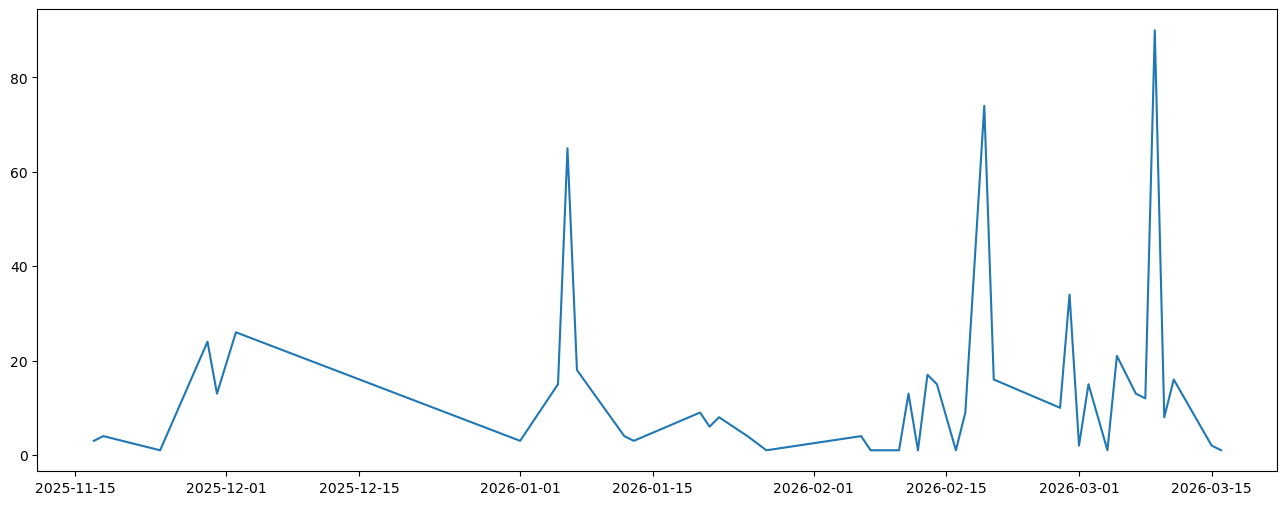

In [40]:
plt.figure(figsize=(16,6))
plt.plot(daily_timeline["only_date"],daily_timeline["message"])

In [41]:
df.head()

,date,user,message,year,month,day,hour,minute,month_num,only_date
0,2025-11-17 01:01:00,Suryadip(B.Tech),Waiting for this message,2025,November,17,1,1,11,2025-11-17
1,2025-11-17 02:18:00,Sarvesh(B.Tech),Waiting for this message,2025,November,17,2,18,11,2025-11-17
2,2025-11-17 11:11:00,Suryadip(B.Tech),Waiting for this message,2025,November,17,11,11,11,2025-11-17
3,2025-11-18 18:55:00,Parineeta(Class CR),Waiting for this message,2025,November,18,18,55,11,2025-11-18
4,2025-11-18 18:56:00,Sarvesh(B.Tech),Waiting for this message,2025,November,18,18,56,11,2025-11-18


In [43]:
df["day_name"]=df["date"].dt.day_name()

In [44]:
df["day_name"].value_counts()

day_name
Tuesday      134
Monday       130
Thursday     110
Saturday      87
Wednesday     54
Friday        47
Sunday        33
Name: count, dtype: int64

In [46]:
period=[]
for hour in df[["day_name","hour"]]["hour"]:
    if hour==23:
        period.append(str(hour)+"-"+str("00"))
    elif hour==0:
        period.append(str("00")+"-"+str(hour+1))
    else:
        period.append(str(hour)+"-"+str(hour+1))

In [47]:
df["period"]=period

In [48]:
df

,date,user,message,year,month,day,hour,minute,month_num,only_date,day_name,period
0,2025-11-17 01:01:00,Suryadip(B.Tech),Waiting for this message,2025,November,17,1,1,11,2025-11-17,Monday,1-2
1,2025-11-17 02:18:00,Sarvesh(B.Tech),Waiting for this message,2025,November,17,2,18,11,2025-11-17,Monday,2-3
2,2025-11-17 11:11:00,Suryadip(B.Tech),Waiting for this message,2025,November,17,11,11,11,2025-11-17,Monday,11-12
3,2025-11-18 18:55:00,Parineeta(Class CR),Waiting for this message,2025,November,18,18,55,11,2025-11-18,Tuesday,18-19
4,2025-11-18 18:56:00,Sarvesh(B.Tech),Waiting for this message,2025,November,18,18,56,11,2025-11-18,Tuesday,18-19
...,...,...,...,...,...,...,...,...,...,...,...,...
590,2026-03-11 10:16:00,Bhawesh Sinha(B.Tech),Kal fir se jana hoga kya,2026,March,11,10,16,3,2026-03-11,Wednesday,10-11
591,2026-03-11 10:16:00,Sarvesh(B.Tech),Bole hai class me aake bata denge,2026,March,11,10,16,3,2026-03-11,Wednesday,10-11
592,2026-03-15 20:07:00,Sarvesh(B.Tech),POLL:,2026,March,15,20,7,3,2026-03-15,Sunday,20-21
593,2026-03-15 20:11:00,No.18 ❤️‍🔥,POLL:,2026,March,15,20,11,3,2026-03-15,Sunday,20-21


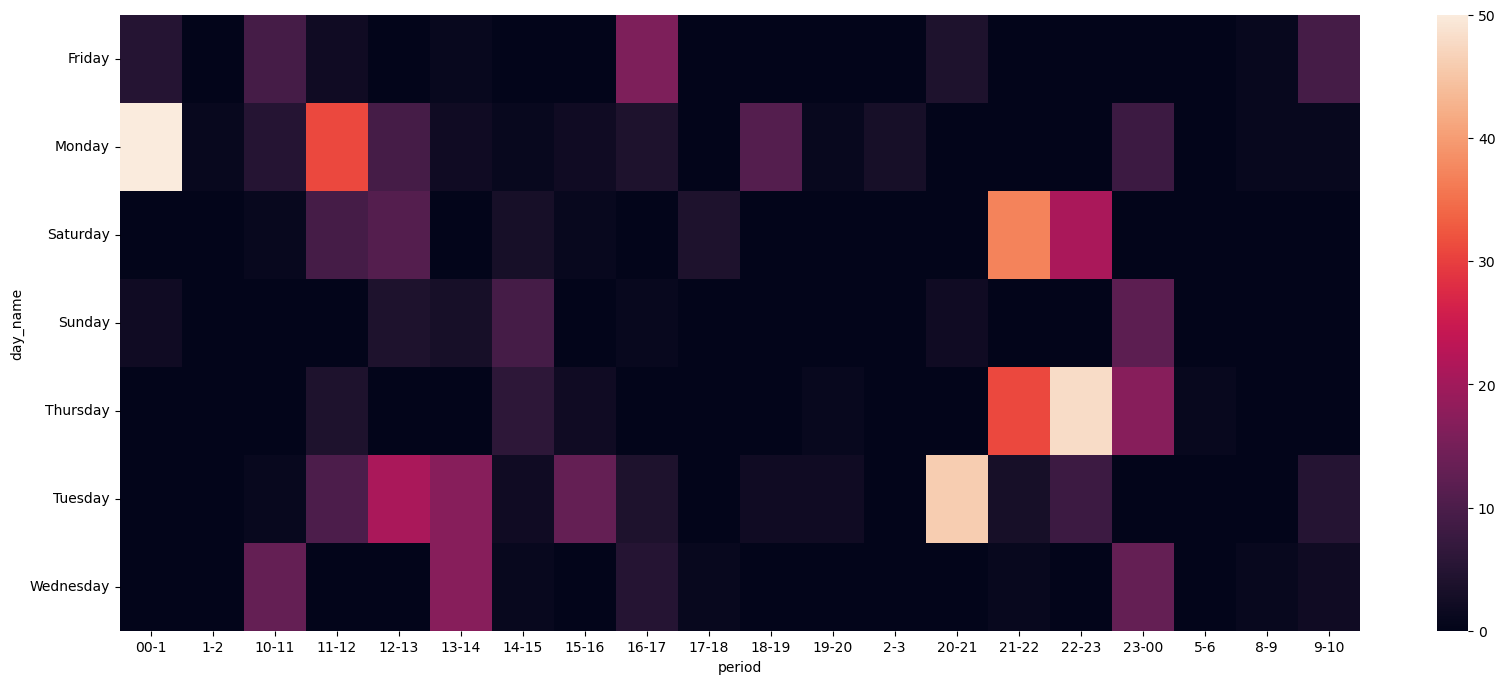

In [50]:
plt.figure(figsize=(20,8))
sns.heatmap(df.pivot_table(index="day_name",columns="period",values="message",aggfunc="count").fillna(0))
plt.yticks(rotation="horizontal")
plt.show()